In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('used_cars.csv')
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [4]:
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

In [5]:
def data_preprocessed(data):
    input = data['model_year']
    output = data['price'].replace(r'[$,]', '', regex=True).astype('int64')
    return input, output  

input, output = data_preprocessed(df)

In [6]:
output

0        10300
1        38005
2        54598
3        15500
4        34999
         ...  
4004    349950
4005     53900
4006     90998
4007     62999
4008     40000
Name: price, Length: 4009, dtype: int64

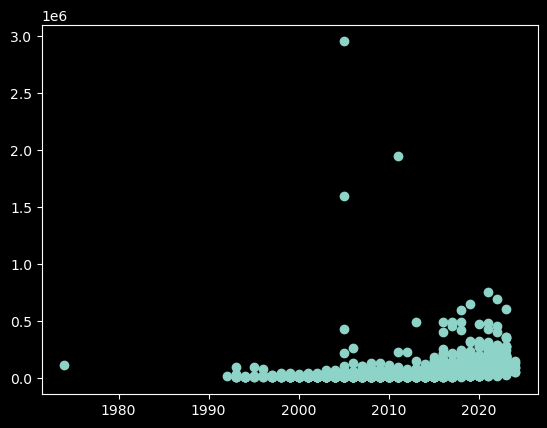

In [9]:
plt.scatter(input, output)

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x_train, x_test, y_train, y_test = train_test_split(input, output, test_size=0.2, random_state=42)

# In kích thước của các tập để kiểm tra
print("Kích thước x_train:", x_train.shape)
print("Kích thước x_test:", x_test.shape)
print("Kích thước y_train:", y_train.shape)
print("Kích thước y_test:", y_test.shape)

Kích thước x_train: (3207,)
Kích thước x_test: (802,)
Kích thước y_train: (3207,)
Kích thước y_test: (802,)


In [12]:
import numpy as np

In [20]:
trainExample = list(zip(x_train, y_train))


In [21]:
# Linear Regression implementation

def phi(x):
    return np.array([x, 1])  # Feature vector [x, 1]

def initialWeightVector():
    return np.zeros(2)  # w = [0, 0]

def trainloss(w):
    return (1.0 / len(trainExample)) * sum((w.dot(phi(x_i)) - y_i)**2 for x_i, y_i in trainExample)

def gradientTrainloss(w):
    return (1.0 / len(trainExample)) * sum(2 * (w.dot(phi(x_i)) - y_i) * phi(x_i) for x_i, y_i in trainExample)

def gradientDescent(L, gradientL, initialWeightVector, eta=0.01, max_iters=20, step=2):
    w = initialWeightVector()
    history = []  # Store loss for plotting
    for i in range(max_iters):
        value = L(w)
        gradient = gradientL(w)
        w_new = w - eta * gradient
        history.append(value)
        # Print every 200 iterations
        if i % step == 0:
            grad_norm = np.linalg.norm(gradient)
            print(f"Epoch {i}: Weight Vector = {w}, TrainLoss = {value:.6f}, Gradient Norm = {grad_norm:.6f}")
        w = w_new
    return w, history

In [22]:
eta = 0.01
w, loss_history = gradientDescent(trainloss, gradientTrainloss, initialWeightVector, eta=eta)

Epoch 0: Weight Vector = [0. 0.], TrainLoss = 4480915805.871531, Gradient Norm = 174063108.338747
Epoch 2: Weight Vector = [-1.41423153e+11 -7.01651362e+07], TrainLoss = 81252300146185382581426454528.000000, Gradient Norm = 1149066310528835840.000000
Epoch 4: Weight Vector = [-9.33595762e+20 -4.63190578e+17], TrainLoss = 3540889534786226430061710865961838518388446461952.000000, Gradient Norm = 7585486658224016594386812928.000000
Epoch 6: Weight Vector = [-6.16307182e+30 -3.05772253e+27], TrainLoss = 154308230967002043715697708483966644365222291534686627111828249903104.000000, Gradient Norm = 50075097768390902577982948387707682816.000000
Epoch 8: Weight Vector = [-4.06851186e+40 -2.01853568e+37], TrainLoss = 6724589939969792989852634226390406816922008030429136378532271951714602786907130850967552.000000, Gradient Norm = 330567507332620113040033094192380661467352924160.000000
Epoch 10: Weight Vector = [-2.68580169e+50 -1.33252323e+47], TrainLoss = 29305053643194425386750103268282505665428

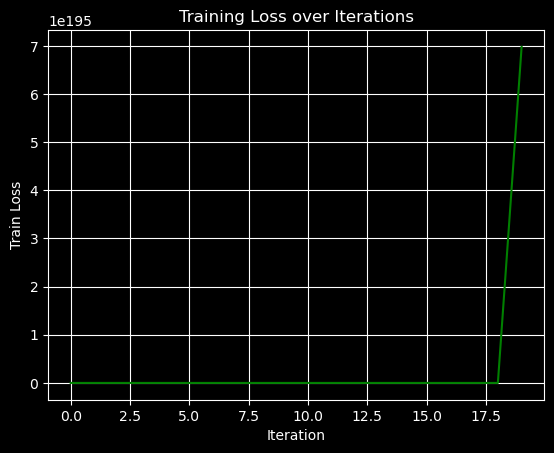

In [23]:
# Plot loss over iterations
plt.plot(loss_history, color='green')
plt.xlabel('Iteration')
plt.ylabel('Train Loss')
plt.title('Training Loss over Iterations')
plt.grid(True)
plt.show()